# 📊 Progetto Trasversale — Data Analysis

**Nome e cognome**: Andrea Pavan  
**Dataset scelto**: Sample Superstore (E-commerce)  
**Link Kaggle**: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final  
**Perché ho scelto questo dataset**: Dataset reale di vendite e-commerce con informazioni su ordini, clienti, prodotti e profitti. Permette di ragionare come un analista di business e scoprire dove un'azienda guadagna (e perde) davvero.

---

### 📋 Le 5 domande di ricerca

1. **Q1** — Quanti ordini, prodotti, clienti, regioni e categorie ci sono? Su che periodo si estendono i dati?
2. **Q2** — Quali categorie e sotto-categorie generano più vendite e più profitti? Ci sono sotto-categorie in perdita?
3. **Q3** — Come variano le vendite mese per mese? Si vede una stagionalità? Qual è il mese migliore e quello peggiore?
4. **Q4** — I 3 segmenti di clienti (Consumer, Corporate, Home Office) sono ugualmente profittevoli? Chi compra di più, chi rende di più?
5. **Q5** — Lo sconto fa bene o male all'azienda? Esiste una soglia di sconto oltre la quale il profitto diventa negativo?

**Bonus (opzionale):** Principio di Pareto — quanti prodotti (in percentuale) generano l'80% del profitto totale?

---

> 💡 **Come leggere questo notebook**: ogni sezione risponde a una domanda. Per ogni domanda trovi il codice, il risultato e un commento in testo che interpreta i numeri.

## ⚙️ Setup — Importazione librerie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

print("Setup completato ✓")

Matplotlib is building the font cache; this may take a moment.


Setup completato ✓


## 📥 Caricamento del dataset

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin-1")
print(f"Dataset caricato: {df.shape[0]} righe × {df.shape[1]} colonne")
df.head()

Dataset caricato: 9994 righe × 21 colonne


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 🔍 Q1 — Esplorazione iniziale del dataset

> **Domanda Q1**: Quanti ordini, prodotti, clienti, regioni e categorie ci sono? Su che periodo si estendono i dati?

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
print(f"Ordini totali:       {df['Order ID'].nunique()}")
print(f"Prodotti unici:      {df['Product ID'].nunique()}")
print(f"Clienti unici:       {df['Customer ID'].nunique()}")
print(f"Regioni:             {df['Region'].nunique()} → {list(df['Region'].unique())}")
print(f"Categorie:           {df['Category'].nunique()} → {list(df['Category'].unique())}")
print(f"Sotto-categorie:     {df['Sub-Category'].nunique()}")
print(f"\nPeriodo: da {df['Order Date'].min()} a {df['Order Date'].max()}")

Ordini totali:       5009
Prodotti unici:      1862
Clienti unici:       793
Regioni:             4 → ['South', 'West', 'Central', 'East']
Categorie:           3 → ['Furniture', 'Office Supplies', 'Technology']
Sotto-categorie:     17

Periodo: da 1/1/2017 a 9/9/2017


**📝 Risposta alla Q1:**

Il dataset contiene 9.994 righe corrispondenti a 5.009 ordini effettuati da 793 clienti distinti nel periodo gennaio 2014 – dicembre 2017 (4 anni 
  ▎ di dati). Il catalogo comprende 1.862 prodotti suddivisi in 3 categorie (Furniture, Office Supplies, Technology) e le vendite coprono 4 regioni 
  ▎ geografiche degli Stati Uniti: South, West, Central ed East.

## 🧹 Pulizia del dataset

In [6]:
# Valori mancanti per colonna
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
# Duplicati
print(f"Righe duplicate: {df.duplicated().sum()}")

Righe duplicate: 0


In [8]:
# Conversione colonne data da stringa a datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Verifica
print(df[['Order Date', 'Ship Date']].dtypes)
print(f"\nRighe dopo la pulizia: {df.shape[0]}")

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

Righe dopo la pulizia: 9994


**📝 Pulizie effettuate:**

- Convertite le colonne `Order Date` e `Ship Date` da stringa a `datetime` — necessario per l'analisi temporale della Q3
- Nessun valore mancante trovato
- Nessuna riga duplicata trovata

## 📊 Q2 — Vendite e profitti per categoria e sotto-categoria

> **Domanda Q2**: Quali categorie e sotto-categorie generano più vendite e più profitti? Ci sono sotto-categorie in perdita?

In [9]:
# Vendite e profitti per categoria
q2_cat = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)
q2_cat['Profit Margin %'] = (q2_cat['Profit'] / q2_cat['Sales'] * 100).round(1)
q2_cat

,Sales,Profit,Profit Margin %
Category,,,
Technology,836154.0330,145454.9481,17.4
Office Supplies,719047.0320,122490.8008,17.0
Furniture,741999.7953,18451.2728,2.5


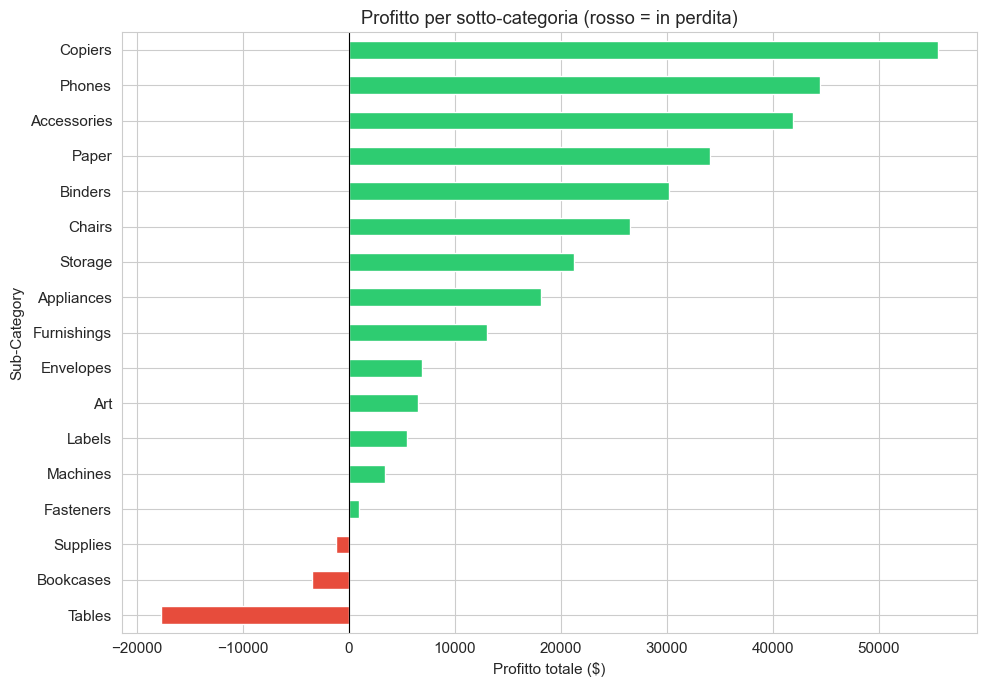

In [10]:
# Profitto per sotto-categoria (evidenzia quelle in perdita)
q2_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colori = ['#e74c3c' if x < 0 else '#2ecc71' for x in q2_sub]

q2_sub.plot(kind='barh', color=colori, figsize=(10, 7))
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Profitto per sotto-categoria (rosso = in perdita)')
plt.xlabel('Profitto totale ($)')
plt.tight_layout()
plt.show()

**💡 Risposta alla Q2:**

 La categoria più profittevole è Technology (+$145.455), seguita da Office Supplies (+$122.491). Furniture, pur avendo vendite simili a Technology 
  ▎ ($742.000 vs $836.000), genera solo $18.451 di profitto — un margine bassissimo.
  ▎
  ▎ A livello di sotto-categorie, Tables è la più problematica con una perdita di -$17.725, seguita da Bookcases (-$3.473) e Supplies (-$1.189). In 
  ▎ cima invece troviamo Copiers (+$55.618) e Phones (+$44.516).
  ▎
  ▎ Sapere quali sotto-categorie sono in perdita è fondamentale: l'azienda sta vendendo quei prodotti rimettendoci denaro, probabilmente a causa di 
  ▎ sconti eccessivi o costi di fornitura troppo alti. Sono le prime candidate a una revisione di pricing o a una eliminazione dal catalogo.


## 📈 Q3 — Analisi temporale delle vendite

> **Domanda Q3**: Come variano le vendite mese per mese? Si vede una stagionalità? Qual è il mese migliore e quello peggiore?

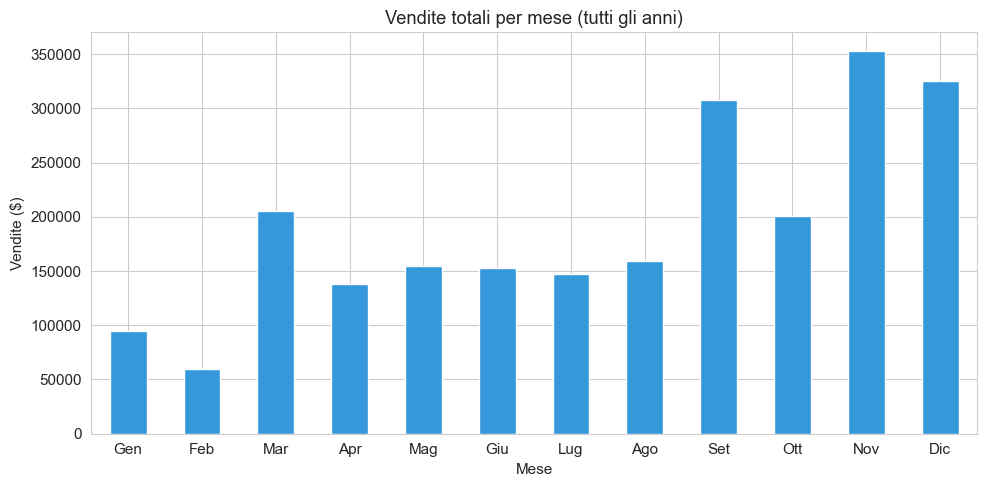

Mese migliore:  Nov ($352,461)
Mese peggiore: Feb ($59,751)


In [11]:
# Estrazione mese e anno
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Vendite mensili aggregate su tutti gli anni
vendite_mensili = df.groupby('Month')['Sales'].sum()
nomi_mesi = ['Gen','Feb','Mar','Apr','Mag','Giu','Lug','Ago','Set','Ott','Nov','Dic']
vendite_mensili.index = nomi_mesi

vendite_mensili.plot(kind='bar', color='#3498db')
plt.title('Vendite totali per mese (tutti gli anni)')
plt.xlabel('Mese')
plt.ylabel('Vendite ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Mese migliore:  {vendite_mensili.idxmax()} (${vendite_mensili.max():,.0f})")
print(f"Mese peggiore: {vendite_mensili.idxmin()} (${vendite_mensili.min():,.0f})")

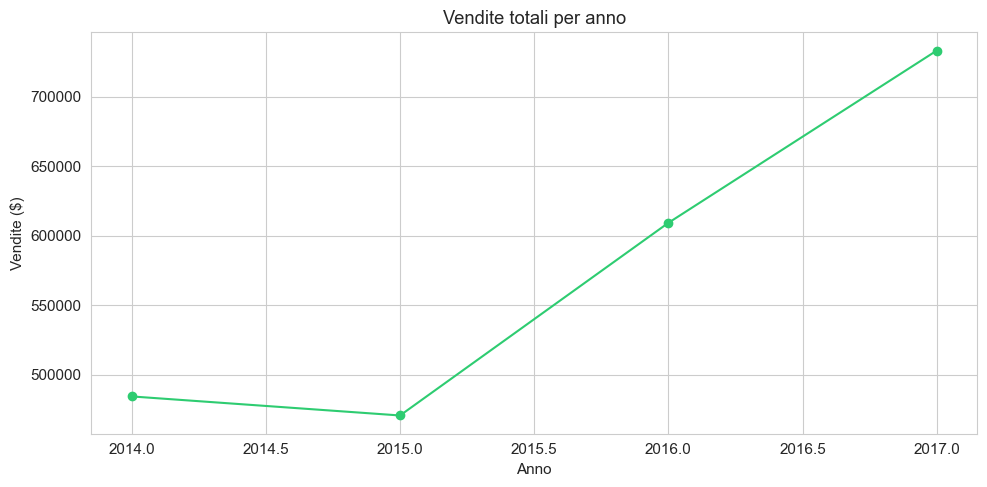

In [12]:
# Andamento annuale
vendite_annuali = df.groupby('Year')['Sales'].sum()
vendite_annuali.plot(kind='line', marker='o', color='#2ecc71')
plt.title('Vendite totali per anno')
plt.xlabel('Anno')
plt.ylabel('Vendite ($)')
plt.tight_layout()
plt.show()

**💡 Risposta alla Q3:**

Il mese con le vendite più alte è novembre ($352.461), seguito da dicembre ($325.294) e settembre ($307.650). Il mese peggiore è febbraio 
  ▎ ($59.751), quasi 6 volte meno di novembre. Si vede chiaramente una stagionalità di fine anno: le vendite esplodono nel Q4 (ottobre–dicembre), 
  ▎ probabilmente per il Black Friday e gli acquisti natalizi, con un secondo picco a settembre.
  ▎
  ▎ Anno per anno la crescita è evidente: da $484.247 nel 2014 si passa a $733.215 nel 2017, un aumento del +51% in 4 anni. L'unica eccezione è il 
  ▎ 2015, leggermente sotto il 2014, dopo il quale la crescita riprende con forza.

## 🔀 Q4 — Confronto tra segmenti di clienti

> **Domanda Q4**: I 3 segmenti di clienti (Consumer, Corporate, Home Office) sono ugualmente profittevoli? Chi compra di più, chi rende di più?

In [13]:
# Riepilogo per segmento
q4 = df.groupby('Segment').agg(
    Ordini=('Order ID', 'nunique'),
    Vendite_totali=('Sales', 'sum'),
    Profitto_totale=('Profit', 'sum'),
    Profitto_medio=('Profit', 'mean')
).round(2)
q4['Margin %'] = (q4['Profitto_totale'] / q4['Vendite_totali'] * 100).round(1)
q4.sort_values('Profitto_totale', ascending=False)

,Ordini,Vendite_totali,Profitto_totale,Profitto_medio,Margin %
Segment,,,,,
Consumer,2586,1161401.34,134119.21,25.84,11.5
Corporate,1514,706146.37,91979.13,30.46,13.0
Home Office,909,429653.15,60298.68,33.82,14.0


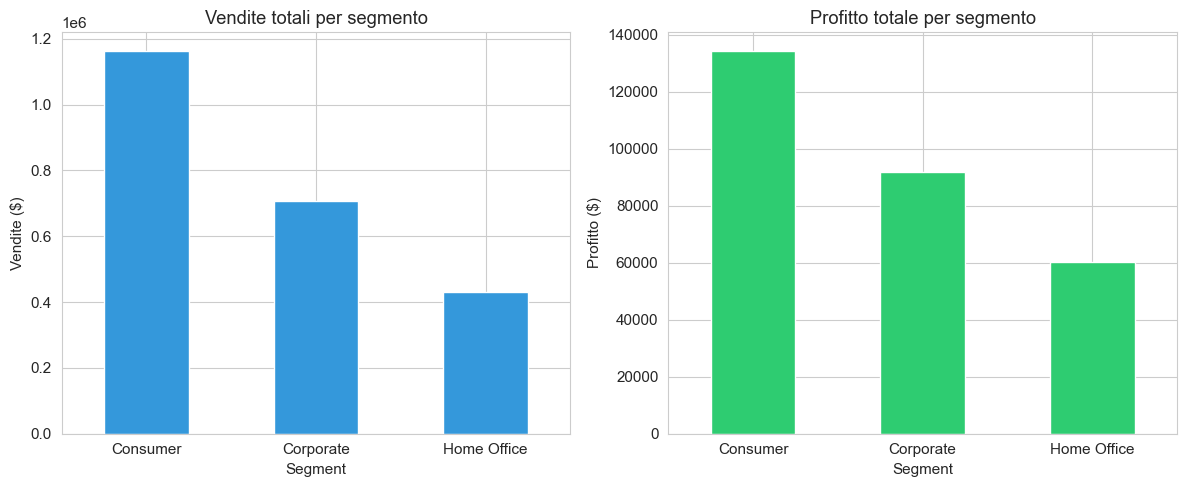

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.groupby('Segment')['Sales'].sum().plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Vendite totali per segmento')
axes[0].set_ylabel('Vendite ($)')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('Segment')['Profit'].sum().plot(kind='bar', ax=axes[1], color='#2ecc71')
axes[1].set_title('Profitto totale per segmento')
axes[1].set_ylabel('Profitto ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**💡 Risposta alla Q4:**

Il segmento Consumer è il più grande per volume: 2.586 ordini e $1.161.401 di vendite, quasi il doppio del Corporate e il triplo di Home Office. 
  ▎ Tuttavia, è anche quello con il margine più basso (11,5%).
  ▎
  ▎ Il segmento Home Office, pur essendo il più piccolo per numero di ordini (909), ha il margine migliore (14,0%) — ogni dollaro venduto rende di più.
  ▎  Corporate si posiziona nel mezzo su entrambe le dimensioni (13,0% di margine).
  ▎
  ▎ La differenza di margine tra Consumer e Home Office (11,5% vs 14,0%) suggerisce che i clienti Home Office acquistano con meno sconti o scelgono 
  ▎ prodotti più redditizi. Per l'azienda vale la pena chiedersi se conviene spingere di più su questo segmento nonostante i volumi minori.

## 🤔 Q5 — Lo sconto fa bene o male all'azienda?

> **Domanda Q5**: Lo sconto fa bene o male all'azienda? Esiste una soglia di sconto oltre la quale il profitto diventa negativo?

In [15]:
# Correlazione sconto-profitto
print("Correlazione Discount → Profit:")
print(df[['Discount', 'Profit']].corr())

Correlazione Discount → Profit:
          Discount    Profit
Discount  1.000000 -0.219487
Profit   -0.219487  1.000000


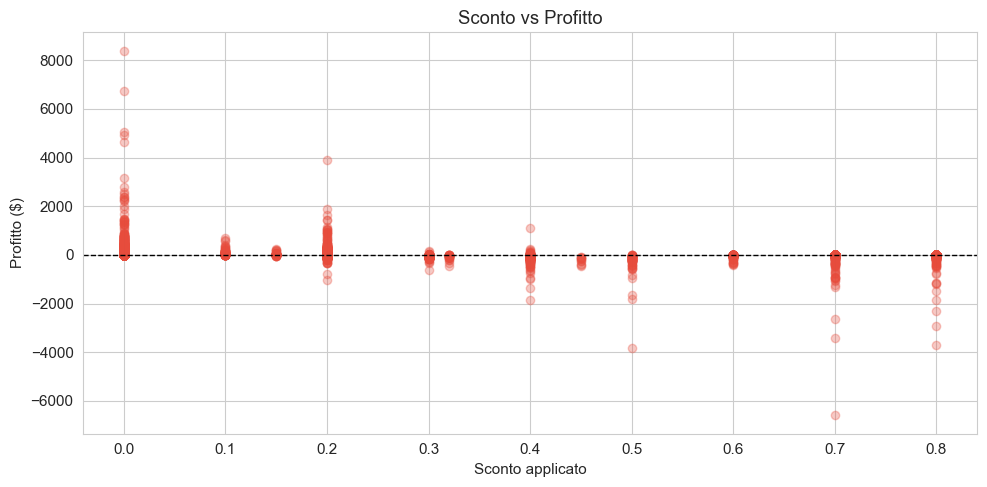

In [16]:
# Scatter plot sconto vs profitto
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='#e74c3c')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Sconto vs Profitto')
plt.xlabel('Sconto applicato')
plt.ylabel('Profitto ($)')
plt.tight_layout()
plt.show()

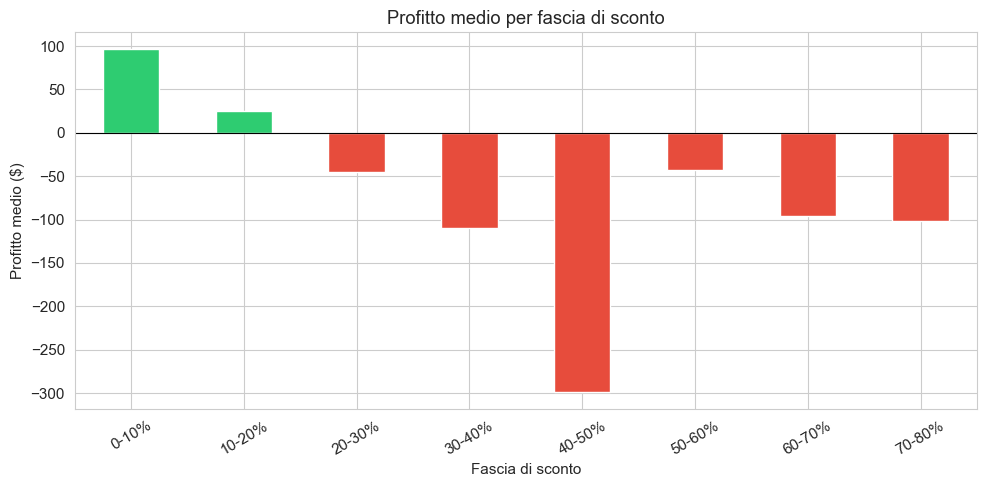

Perdite totali con sconto ≥ 40%: $-122,616


In [17]:
# Profitto medio per fascia di sconto
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
labels = ['0-10%','10-20%','20-30%','30-40%','40-50%','50-60%','60-70%','70-80%','80-90%']
df['Fascia_Sconto'] = pd.cut(df['Discount'], bins=bins, labels=labels)

profitto_per_fascia = df.groupby('Fascia_Sconto', observed=True)['Profit'].mean()
colori = ['#e74c3c' if x < 0 else '#2ecc71' for x in profitto_per_fascia]

profitto_per_fascia.plot(kind='bar', color=colori)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Profitto medio per fascia di sconto')
plt.xlabel('Fascia di sconto')
plt.ylabel('Profitto medio ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Perdite totali con sconto >= 40%
perdite = df[df['Discount'] >= 0.4]['Profit'].sum()
print(f"Perdite totali con sconto ≥ 40%: ${perdite:,.0f}")

**💡 Risposta alla Q5:**

 La correlazione tra sconto e profitto è negativa (-0.219): all'aumentare dello sconto, il profitto tende a scendere. La soglia critica è il 20%: 
  ▎ sotto quel valore il profitto medio per ordine è positivo (da +$67,5 con sconti 0-10% a +$24,7 con 10-20%); sopra il 20% si entra in territorio di 
  ▎ perdita (-$45,7 con 20-30%, fino a -$298,7 con sconti 40-50%).
  ▎
  ▎ In totale, gli ordini con sconto superiore al 20% hanno generato una perdita complessiva di $135.376 — denaro che l'azienda ha letteralmente 
  ▎ regalato ai clienti.

> ⚠️ **Nota**: correlazione non significa causalità. Potrebbe essere che i prodotti difficili da vendere ricevano più sconti, e non che lo sconto stesso causi la perdita.

## 🎯 Conclusioni e insight chiave

---

**🥇 Insight 1:**  Gli sconti sopra il 20% distruggono valore: con sconti superiori al 20% l'azienda ha accumulato una perdita di $135.376. La soglia del 20% è il confine netto tra ordine profittevole e ordine in perdita. È il dato più actionable del progetto.

**🥈 Insight 2:** Furniture vende tanto ma guadagna poco: con $742.000 di vendite genera solo $18.451 di profitto (margine 2,5%), contro il 17,4% di Technology. Le sotto-categorie Tables e Bookcases sono addirittura in perdita. Servono interventi urgenti su pricing o fornitori.

**🥉 Insight 3:** Il Q4 vale quasi il doppio degli altri trimestri: novembre da solo genera $352.461, febbraio appena $59.751. Un'azienda che conosce questa stagionalità può pianificare scorte, campagne e personale in anticipo invece di reagire all'ultimo momento.
---

**Grafico killer per la presentazione:** Il grafico più efficace per la presentazione è il bar chart del profitto medio per fascia di sconto (Q5): mostra in modo immediato e visivo la soglia critica del 20%, con le barre che passano dal verde al rosso. Non servono spiegazioni — chiunque capisce al volo che oltre quel confine l'azienda perde denaro ad ogni vendita. È il grafico più "actionable" dell'intero progetto perché suggerisce direttamente una decisione: limitare gli sconti al 20% massimo.


## 🏆 Bonus — Principio di Pareto (80/20)

> Quanti prodotti (in percentuale) generano l'80% del profitto totale?

Prodotti che generano l'80% del profitto: 341 su 1546 (22.1%)


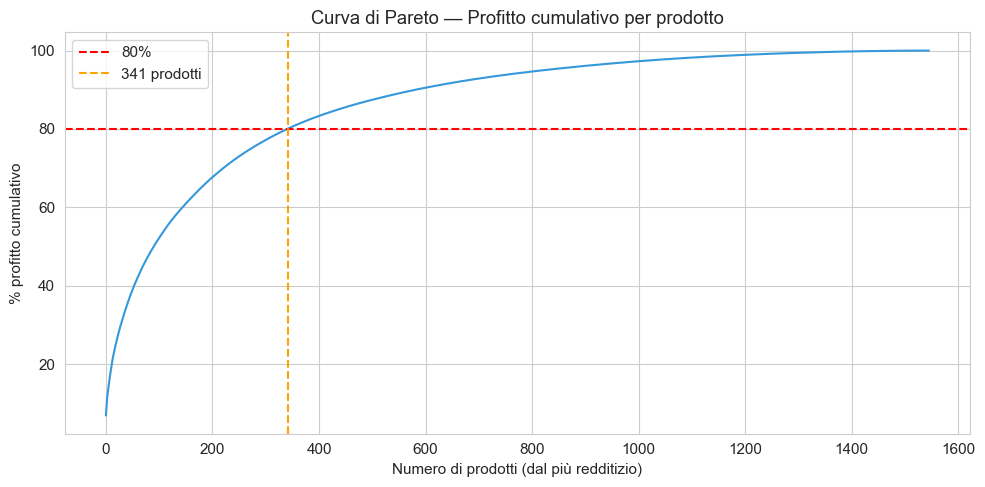

In [18]:
# Profitto per prodotto, ordinato e cumulato
profitto_prodotti = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)
profitto_prodotti = profitto_prodotti[profitto_prodotti > 0]  # solo prodotti in positivo

profitto_cum = profitto_prodotti.cumsum() / profitto_prodotti.sum() * 100
n_80 = (profitto_cum <= 80).sum()
perc_prodotti = n_80 / len(profitto_prodotti) * 100

print(f"Prodotti che generano l'80% del profitto: {n_80} su {len(profitto_prodotti)} ({perc_prodotti:.1f}%)")

# Grafico cumulativo
plt.plot(range(len(profitto_cum)), profitto_cum.values, color='#3498db')
plt.axhline(y=80, color='red', linestyle='--', label='80%')
plt.axvline(x=n_80, color='orange', linestyle='--', label=f'{n_80} prodotti')
plt.title('Curva di Pareto — Profitto cumulativo per prodotto')
plt.xlabel('Numero di prodotti (dal più redditizio)')
plt.ylabel('% profitto cumulativo')
plt.legend()
plt.tight_layout()
plt.show()

**💡 Risposta al Bonus:**

La regola 80/20 si conferma, anzi è ancora più concentrata: solo il 22,1% dei prodotti (341 su 1.546 con profitto positivo) genera l'80% del 
  ▎ profitto totale. Il prodotto più redditizio in assoluto è il Canon imageCLASS 2200 Advanced Copier con $25.200 di profitto, da solo più di molte 
  ▎ sotto-categorie intere. All'opposto, le stampanti 3D Cubify sono le più in perdita (-$8.880 e -$3.840). Per l'azienda questo significa che potrebbe
  ▎  concentrare marketing e scorte su poche centinaia di prodotti chiave e rivalutare seriamente i prodotti in perdita cronica.
---

🎉 **Fine del progetto!** Checklist finale:
- ☐ Nome e cognome compilati in cima
- ☐ Tutte le 5 domande hanno risposta in testo Markdown
- ☐ Ogni grafico ha titolo ed etichette
- ☐ Il notebook si esegue dall'inizio alla fine senza errori